# Introduction to the `InSituExperiment` class
## Background

<img src="../../demo_data/demo_screenshots/experiment_levels.jpg" height="300"/>

<p>In addition to the sample, cellular, and subcellular levels, a spatial transcriptomics dataset typically includes an experiment level that contains information about clinical and experimental cohorts, conditions, or treatments. Most current computational frameworks lack functionalities to incorporate this level into the analysis. To address this, <code>InSituPy</code> introduces the <code>InSituExperiment</code> class, which manages spatial transcriptomics data and the corresponding metadata of multiple samples simultaneously.</p>


## Structure
<img src="../../demo_data/demo_screenshots/insituexperiment_structure.jpg" height="200"/>

An `InSituExperiment` object consists of multiple `InSituData` objects paired with their corresponding metadata.

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from insitupy import InSituData, InSituExperiment, CACHE

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Load Xenium data into `InSituData` object

Now the Xenium data can be parsed by providing the data path to the `InSituPy` project folder.

In [4]:
insitupy_project = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(insitupy_project)
xd.load_all(skip="transcripts")
xd

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project

    ➤ images
       CD20:	(25778, 35416)
       HE:	(25778, 35416, 3)
       HER2:	(25778, 35416)
       nuclei:	(25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 156447 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_location', 'leiden', 'leiden_colors', 'log1p', 'neig

### Create `InSituExperiment`

<img src="../../demo_data/demo_screenshots/insituexperiment_generation.jpg" height="250"/>

*Options to generate an InSituExperiment object*

#### Method 1: Manually add `InSituData` objects

In [5]:
exp = InSituExperiment()
exp.add(
    data=xd,
    metadata={
        "slide_id": xd.slide_id,
        "sample_id": xd.sample_id,
        "patient": "A"
    }
    )

In [6]:
exp

InSituExperiment with 1 samples:
           uid  CITAR slide_id    sample_id patient
0     9f3f7f9b  ++-++  0001879  Replicate 1       A

In the same way also other datasets can be added. For demonstration purposes, we just add the same dataset again and change the metadata.

In [7]:
exp.add(
    data=xd,
    metadata={
        "slide_id": xd.slide_id,
        "sample_id": xd.sample_id,
        "patient": "A",
        "therapy": "drugB"
    }
    )

In [8]:
exp

InSituExperiment with 2 samples:
           uid  CITAR slide_id    sample_id patient therapy
0     9f3f7f9b  ++-++  0001879  Replicate 1       A     NaN
1     106c2b98  ++-++  0001879  Replicate 1       A   drugB

#### Method 2: From config file

As config file either a csv file or an excel file can be used.

Example of a valid configuration file:

| directory         | experiment_name | date       | patient    |
|-------------------|-----------------|------------|------------|
| /path/to/dataset1 | Experiment 1    | 2023-09-01 | Patient A  |
| /path/to/dataset2 | Experiment 2    | 2023-09-02 | Patient B  |

In [9]:
import pandas as pd
from insitupy import CACHE

# Define the data
data = {
    "directory": [f"{CACHE}\\out\\demo_insitupy_project", f"{CACHE}\\out\\demo_insitupy_project"],
    "patient": ["A", "B"],
    "therapy": ["drugA", "drugB"]
}

# Create a DataFrame
config_df = pd.DataFrame(data)

# Write the DataFrame to a CSV file
config_df.to_csv('../../demo_data/demo_experiment/insituexperiment_config.csv', index=False)

In [10]:
exp = InSituExperiment.from_config(config_path="../../demo_data/demo_experiment/insituexperiment_config.csv")

100%|██████████| 2/2 [00:00<00:00, 242.79it/s]


In [11]:
exp

InSituExperiment with 2 samples:
           uid  CITAR slide_id    sample_id patient therapy
0     e70130ba  -----  0001879  Replicate 1       A   drugA
1     b6bcb5d2  -----  0001879  Replicate 1       B   drugB

In [12]:
exp.load_all()

100%|██████████| 2/2 [00:08<00:00,  4.03s/it]


In [13]:
exp

InSituExperiment with 2 samples:
           uid  CITAR slide_id    sample_id patient therapy
0     e70130ba  +++++  0001879  Replicate 1       A   drugA
1     b6bcb5d2  +++++  0001879  Replicate 1       B   drugB

#### Method 3: From regions

We can also use regions from an `InSituData` object to split the data into separate datasets and create an `InSituExperiment` from them. This can be used to select the most interesting regions and focus on them for the analysis or to split a TMA dataset into separate datasets for each core.

In [14]:
exp = InSituExperiment.from_regions(
    data=xd, region_key="TMA"
)

A-1
A-2
A-3
B-1
B-2
B-3


In [15]:
exp

InSituExperiment with 6 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     d5933ddc  ++-++  0001879  Replicate 1        TMA         A-1
1     a2e80cc4  ++--+  0001879  Replicate 1        TMA         A-2
2     48ac6b5f  ++--+  0001879  Replicate 1        TMA         A-3
3     9c6648b2  ++-++  0001879  Replicate 1        TMA         B-1
4     4119649d  ++-++  0001879  Replicate 1        TMA         B-2
5     b56cbd06  ++-++  0001879  Replicate 1        TMA         B-3

## Work with viewer windows and `InSituExperiment`

One can interactively display the data for individual datasets inside an `InSituExperiment` using `.show(<index>)`, where `<index>` specifies the index of the data in the metadata. Since version `0.9.0` multiple viewer windows can be opened in parallel. In the napari window annotations can be made and synced back to the data in `InSituExperiment` using the "Sync Geometries" button on the bottom right.

In [16]:
# visualize data
exp.show(3)

Example screenshot of data from one of the cropped cores:

<img src="../../demo_data/demo_screenshots/TMA_example.jpg" class="center" height="300"/>

## Plot overview of metadata and QC metrics

In [17]:
from insitupy.plotting import plot_overview

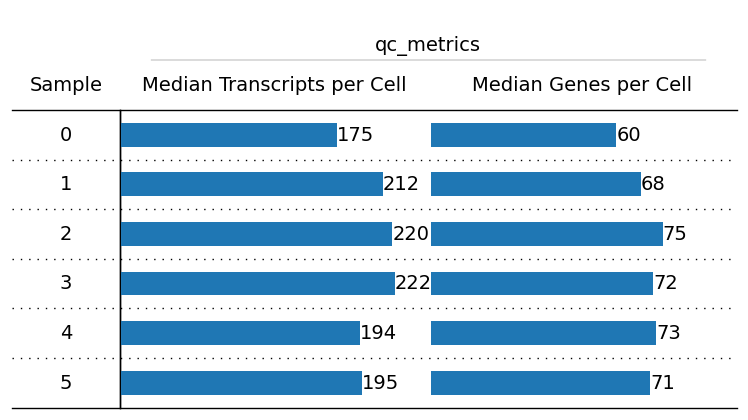

In [18]:
plot_overview(exp)

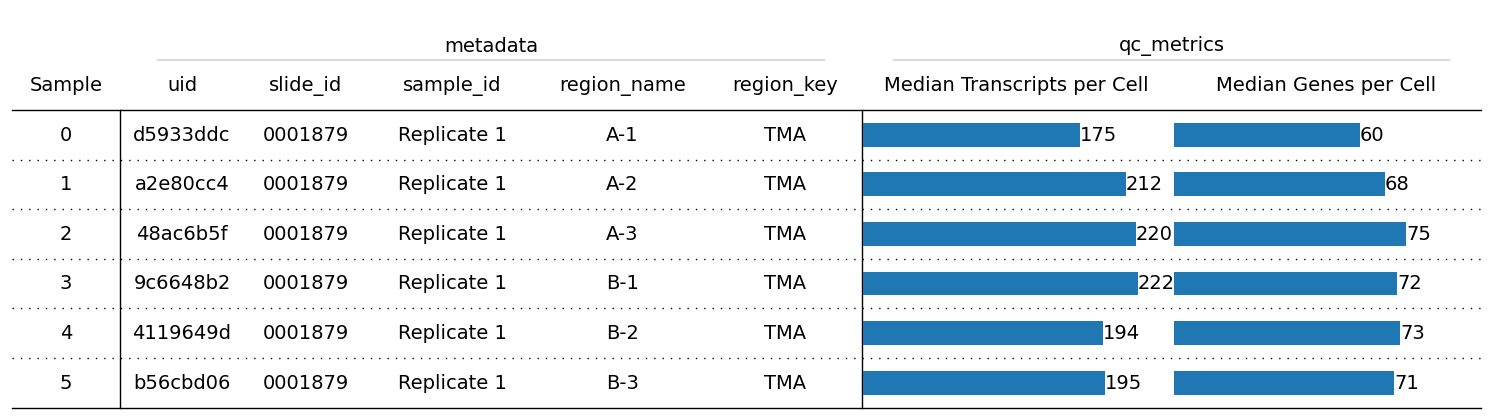

In [19]:
plot_overview(exp, cells_layer="main", columns_to_plot=["uid", "slide_id", "sample_id", "region_name", "region_key"], index=True)

## Iterate through `InSituExperiment`

The `.iterdata()` method returns a generator object, allowing you to iterate through the metadata and data of each dataset in the `InSituExperiment`. The individual datasets are returned as `InSituData` objects.

In [20]:
for metadata, data in exp.iterdata():
    print(f"Metadata:\n{metadata[:3]}\nData:\n{data}")

Metadata:
uid             d5933ddc
slide_id         0001879
sample_id    Replicate 1
Name: 0, dtype: object
Data:
InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		None

    ➤ images
       CD20:	(4706, 4706)
       HE:	(4706, 4706, 3)
       HER2:	(4706, 4706)
       nuclei:	(4706, 4706)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 4847 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_lo

## Add new metadata

In the following section different scenarios for adding new metadata are shown.

In [21]:
exp1 = InSituExperiment.from_regions(
    data=xd, region_key="demo_regions"
)

Region1
Region2
Region3


In [22]:
exp1

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name
0     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1
1     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2
2     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3

In [23]:
exp2 = exp1.copy()
exp2.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata.csv",
    by="region_name", overwrite=True
)

In [24]:
exp2

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_name therapy   organ      test region_key
0     0d1f50a5  ++-++  0001879  Replicate 1     Region1   drugC   liver  negative       key1
1     16fe63e1  ++-++  0001879  Replicate 1     Region2   drugD    lung      test       key3
2     7900691c  ++-++  0001879  Replicate 1     Region3   drugE  spleen  positive       key2

In [25]:
exp3 = exp1.copy()
exp3.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata.csv",
    by="region_name", overwrite=False
)

In [26]:
exp3

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name   organ      test therapy
0     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1   liver  negative   drugC
1     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2    lung      test   drugD
2     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3  spleen  positive   drugE

In [27]:
exp4 = exp1.copy()
exp4.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata2.csv",
    by="region_name", overwrite=False
)

In [28]:
exp4

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name   organ      test therapy
0     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1   liver  negative   drugC
1     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2     NaN       NaN     NaN
2     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3  spleen  positive   drugE

In [29]:
exp5 = exp1.copy()
exp5.append_metadata(
    new_metadata="../../demo_data/demo_experiment/insituexperiment_new_metadata2.csv",
    by="region_name", overwrite=True
)

In [30]:
exp5

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_name therapy   organ      test region_key
0     0d1f50a5  ++-++  0001879  Replicate 1     Region1   drugC   liver  negative       key1
1     16fe63e1  ++-++  0001879  Replicate 1     Region2     NaN     NaN       NaN        NaN
2     7900691c  ++-++  0001879  Replicate 1     Region3   drugE  spleen  positive       key2

Concatenate multiple `InSituExperiment` objects

In [32]:
exp

InSituExperiment with 6 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     d5933ddc  ++-++  0001879  Replicate 1        TMA         A-1
1     a2e80cc4  ++--+  0001879  Replicate 1        TMA         A-2
2     48ac6b5f  ++--+  0001879  Replicate 1        TMA         A-3
3     9c6648b2  ++-++  0001879  Replicate 1        TMA         B-1
4     4119649d  ++-++  0001879  Replicate 1        TMA         B-2
5     b56cbd06  ++-++  0001879  Replicate 1        TMA         B-3

In [33]:
exp1

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name
0     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1
1     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2
2     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3

In [34]:
exp_concat = InSituExperiment.concat(
    objs={
        "exp_TMA": exp,
        "exp_demo_regions": exp1
    },
    new_col_name="name"
    )

C:\Users\ge37voy\Github\InSituPy\insitupy\experiment\data.py:240: UserWarning: Observation names are not unique across all datasets.
  warnings.warn("Observation names are not unique across all datasets.")


In [35]:
exp_concat

InSituExperiment with 9 samples:
           uid  CITAR slide_id    sample_id    region_key region_name            name
0     d5933ddc  ++-++  0001879  Replicate 1           TMA         A-1         exp_TMA
1     a2e80cc4  ++--+  0001879  Replicate 1           TMA         A-2         exp_TMA
2     48ac6b5f  ++--+  0001879  Replicate 1           TMA         A-3         exp_TMA
3     9c6648b2  ++-++  0001879  Replicate 1           TMA         B-1         exp_TMA
4     4119649d  ++-++  0001879  Replicate 1           TMA         B-2         exp_TMA
5     b56cbd06  ++-++  0001879  Replicate 1           TMA         B-3         exp_TMA
6     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1  exp_demo_re...
7     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2  exp_demo_re...
8     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3  exp_demo_re...

In [36]:
exp_concat = InSituExperiment.concat(
    objs=[exp, exp1])

C:\Users\ge37voy\Github\InSituPy\insitupy\experiment\data.py:240: UserWarning: Observation names are not unique across all datasets.
  warnings.warn("Observation names are not unique across all datasets.")


In [37]:
exp_concat

InSituExperiment with 9 samples:
           uid  CITAR slide_id    sample_id    region_key region_name
0     d5933ddc  ++-++  0001879  Replicate 1           TMA         A-1
1     a2e80cc4  ++--+  0001879  Replicate 1           TMA         A-2
2     48ac6b5f  ++--+  0001879  Replicate 1           TMA         A-3
3     9c6648b2  ++-++  0001879  Replicate 1           TMA         B-1
4     4119649d  ++-++  0001879  Replicate 1           TMA         B-2
5     b56cbd06  ++-++  0001879  Replicate 1           TMA         B-3
6     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1
7     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2
8     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3

## Indexing and selection of data within `InSituExperiment`

The `InSituExperiment` class allows simple selection and filtering of data using indices or True/False masks.

### Example 1: Select datasets by index

In [38]:
exp_indexed = exp_concat[:3]

In [39]:
exp_indexed

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     d5933ddc  ++-++  0001879  Replicate 1        TMA         A-1
1     a2e80cc4  ++--+  0001879  Replicate 1        TMA         A-2
2     48ac6b5f  ++--+  0001879  Replicate 1        TMA         A-3

In [40]:
exp_indexed.show(2)

Also a list of indices can be used for this.

In [41]:
exp_concat[[0,1,4]]

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     d5933ddc  ++-++  0001879  Replicate 1        TMA         A-1
1     a2e80cc4  ++--+  0001879  Replicate 1        TMA         A-2
2     4119649d  ++-++  0001879  Replicate 1        TMA         B-2

### Example 2: Select only datasets with a "1" in the region name using a mask

In [42]:
filtering_mask = exp_concat.metadata["region_name"].str.contains("1", na=False) # NaN values are filled with False
exp_filtered = exp_concat[filtering_mask]

### Example 3: Query data

The `.query()` function can be used to the [`pandas.DataFrame.query`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html) function.

In [43]:
exp_concat.query(
    criteria="region_key == 'demo_regions'"
)

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id    region_key region_name
0     0d1f50a5  ++-++  0001879  Replicate 1  demo_regions     Region1
1     16fe63e1  ++-++  0001879  Replicate 1  demo_regions     Region2
2     7900691c  ++-++  0001879  Replicate 1  demo_regions     Region3

## Save `InSituExperiment`

In [44]:
exp_concat.saveas(CACHE / "out/test_insituexperiment", overwrite=True)

100%|██████████| 9/9 [00:49<00:00,  5.55s/it]


## Reload `InSituExperiment`

In [45]:
exp_reloaded = InSituExperiment.read(CACHE / "out/test_insituexperiment/")

100%|██████████| 9/9 [00:00<00:00, 857.07it/s]


In [46]:
exp_reloaded.load_all()

100%|██████████| 9/9 [00:04<00:00,  1.92it/s]


In [47]:
exp_reloaded

InSituExperiment with 9 samples:
           uid  CITAR  slide_id    sample_id    region_key region_name
0     d5933ddc  ++-++      1879  Replicate 1           TMA         A-1
1     a2e80cc4  ++--+      1879  Replicate 1           TMA         A-2
2     48ac6b5f  ++--+      1879  Replicate 1           TMA         A-3
3     9c6648b2  ++-++      1879  Replicate 1           TMA         B-1
4     4119649d  ++-++      1879  Replicate 1           TMA         B-2
5     b56cbd06  ++-++      1879  Replicate 1           TMA         B-3
6     0d1f50a5  ++-++      1879  Replicate 1  demo_regions     Region1
7     16fe63e1  ++-++      1879  Replicate 1  demo_regions     Region2
8     7900691c  ++-++      1879  Replicate 1  demo_regions     Region3

In [48]:
exp_reloaded.show(2)

In [49]:
exp_reloaded.save()

100%|██████████| 9/9 [00:13<00:00,  1.53s/it]


In [50]:
exp_reloaded = InSituExperiment.read(CACHE / "out/test_insituexperiment/")

100%|██████████| 9/9 [00:00<00:00, 911.25it/s]


In [51]:
exp_reloaded.load_all()

100%|██████████| 9/9 [00:04<00:00,  2.12it/s]


In [52]:
exp_reloaded.data[2]

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\test_insituexperiment\data-002

    ➤ images
       CD20:	(4706, 4705)
       HE:	(4706, 4705, 3)
       HER2:	(4706, 4705)
       nuclei:	(4706, 4705)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 1807 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_location', 'leiden', 'leiden_colors', 'log1p', 'neigh

In [53]:
exp_reloaded.show(2)

INFO: Added 3 new annotations to key 'TestKey'


Annotations or regions can now be added to the individual datasets and by pressing the "Sync Geometries" button they are saved in the corresponding `InSituData` object:

In [56]:
exp_reloaded.data[2]

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\test_insituexperiment\data-002

    ➤ images
       CD20:	(4706, 4705)
       HE:	(4706, 4705, 3)
       HER2:	(4706, 4705)
       nuclei:	(4706, 4705)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 1807 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_publ_colors', 'cell_type_tacco_colors', 'counts_location', 'leiden', 'leiden_colors', 'log1p', 'neigh